# Refinamento da Segmentação de Mercados

## Objetivo

Aprimorar a segmentação inicial dos municípios brasileiros reduzindo o impacto de valores extremos presentes nas variáveis econômicas e demográficas.

## Problema Identificado

A primeira clusterização revelou forte concentração econômica em poucos municípios, especialmente São Paulo e Rio de Janeiro.

Esse comportamento pode influenciar excessivamente a formação dos grupos, reduzindo a capacidade do modelo de identificar padrões intermediários.

## Estratégia Adotada

- Transformação Logarítmica
- Nova Padronização
- Reexecução do K-Means
- Comparação dos Resultados

## Resultado Esperado

Obter clusters mais equilibrados e representativos dos diferentes perfis de mercado existentes no Brasil.

In [2]:
# — Carregamento da Base Analítica ──────────────────────────────
# COMO funciona: carrega a base consolidada produzida na etapa de tratamento.
# ONDE é usado: ponto de partida do refinamento da clusterização.
# POR QUE esta escolha: garante que a análise seja reproduzível sem depender
# de notebooks anteriores.
# QUANDO rodar: início do notebook.
# O QUE produz: DataFrame contendo todos os indicadores municipais.

import pandas as pd

df_municipios = pd.read_csv(
    "dados/processados/base_municipios_enriquecida.csv",
    encoding="utf-8-sig"
)

print("Dimensões:")
print(df_municipios.shape)

Dimensões:
(5570, 16)


In [3]:
# — Transformação Logarítmica das Variáveis ──────────────────────
# COMO funciona: aplica logaritmo nas variáveis de grande amplitude.
# ONDE é usado: preparação dos dados para nova clusterização.
# POR QUE esta escolha: reduzir a influência excessiva de municípios extremos.
# QUANDO rodar: após carregar a base analítica.
# O QUE produz: conjunto de variáveis transformadas para modelagem.

import numpy as np

X_log = pd.DataFrame()

X_log["pib_municipal"] = np.log1p(
    df_municipios["pib_municipal"]
)

X_log["pib_per_capita"] = np.log1p(
    df_municipios["pib_per_capita"]
)

X_log["populacao_residente"] = np.log1p(
    df_municipios["populacao_residente"]
)

X_log["area_km2"] = np.log1p(
    df_municipios["area_km2"]
)

X_log["densidade_demografica"] = np.log1p(
    df_municipios["densidade_demografica"]
)

print("Dimensões:")
print(X_log.shape)

display(X_log.head())

Dimensões:
(5570, 5)


,pib_municipal,pib_per_capita,populacao_residente,area_km2,densidade_demografica
0,13.731608,3.779184,9.975576,8.863351,1.396245
1,15.152971,3.697329,11.480753,8.395606,3.130263
2,12.576891,4.010146,8.585226,7.181860,1.623341
3,14.977251,3.631714,11.372375,8.241176,3.174297
4,13.713589,4.057584,9.673508,7.931752,1.903599


In [4]:
# — Padronização das Variáveis ──────────────────────────────────
# COMO funciona: coloca todas as variáveis na mesma escala.
# ONDE é usado: preparação para algoritmos de clusterização.
# POR QUE esta escolha: evitar que variáveis maiores dominem o modelo.
# QUANDO rodar: após a transformação logarítmica.
# O QUE produz: matriz padronizada para utilização no K-Means.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

print("Dimensões:")
print(X_scaled.shape)

Dimensões:
(5570, 5)


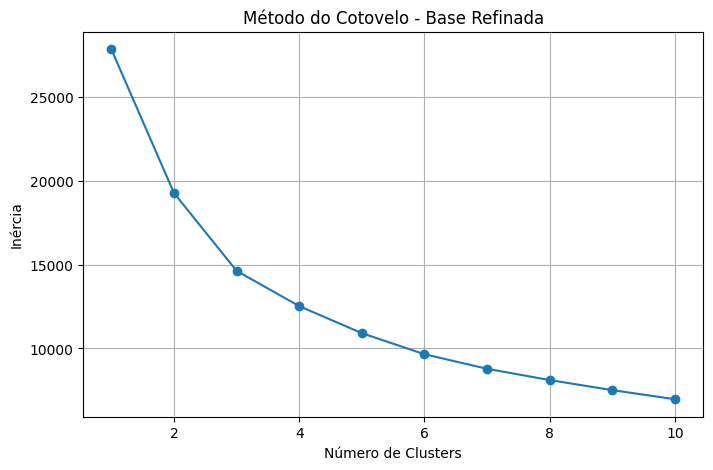

In [5]:
# — Método do Cotovelo (Base Refinada) ──────────────────────────
# COMO funciona: executa o K-Means com diferentes quantidades de clusters.
# ONDE é usado: definição da quantidade ideal de grupos.
# POR QUE esta escolha: identificar o ponto onde adicionar novos clusters
# deixa de gerar ganhos significativos na segmentação.
# QUANDO rodar: após transformação logarítmica e padronização.
# O QUE produz: gráfico do Método do Cotovelo.

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercia.append(
        modelo.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercia,
    marker="o"
)

plt.title(
    "Método do Cotovelo - Base Refinada"
)

plt.xlabel(
    "Número de Clusters"
)

plt.ylabel(
    "Inércia"
)

plt.grid(True)

plt.show()

In [6]:
# — Avaliação dos Clusters com Silhouette Score ─────────────────
# COMO funciona: calcula a qualidade da separação para diferentes quantidades
# de clusters.
# ONDE é usado: validação estatística da segmentação.
# POR QUE esta escolha: complementar a análise do Método do Cotovelo.
# QUANDO rodar: após o gráfico de inércia.
# O QUE produz: tabela com os valores de Silhouette Score.

from sklearn.metrics import silhouette_score

resultados = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = modelo.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        clusters
    )

    resultados.append(
        [k, score]
    )

df_silhouette = pd.DataFrame(
    resultados,
    columns=[
        "clusters",
        "silhouette"
    ]
)

display(
    df_silhouette
)

,clusters,silhouette
0,2,0.334015
1,3,0.305511
2,4,0.249912
3,5,0.246734
4,6,0.244753
5,7,0.242728
6,8,0.243554
7,9,0.249530
8,10,0.247658


## Insight de Negócio — Refinamento da Clusterização

A aplicação da transformação logarítmica reduziu o impacto de municípios extremamente discrepantes, como São Paulo e Rio de Janeiro.

Embora os índices de Silhouette tenham diminuído em relação à primeira execução do modelo, o resultado passou a refletir uma segmentação mais realista dos municípios brasileiros.

Esse comportamento indica que a clusterização inicial era fortemente influenciada pelos extremos econômicos, enquanto a versão refinada busca identificar padrões estruturais entre municípios comparáveis.

Dessa forma, optou-se por utilizar a versão refinada da clusterização como modelo principal para análise dos perfis de mercado.


In [7]:
# — Clusterização Final Refinada ────────────────────────────────
# COMO funciona: executa o K-Means definitivo utilizando as variáveis
# transformadas e padronizadas.
# ONDE é usado: geração da segmentação final dos municípios.
# POR QUE esta escolha: obter grupos mais comparáveis e menos influenciados
# por valores extremos.
# QUANDO rodar: após validação do Método do Cotovelo e Silhouette Score.
# O QUE produz: coluna cluster_refinado com a classificação final.

from sklearn.cluster import KMeans

modelo_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_municipios["cluster_refinado"] = modelo_final.fit_predict(
    X_scaled
)

display(
    df_municipios["cluster_refinado"]
    .value_counts()
    .sort_index()
)

cluster_refinado
0    1476
1    2057
2     914
3    1123
Name: count, dtype: int64

In [8]:
# — Perfil Estatístico dos Clusters Refinados ───────────────────
# COMO funciona: calcula médias das principais variáveis para cada cluster.
# ONDE é usado: interpretação dos grupos encontrados pelo K-Means.
# POR QUE esta escolha: identificar as características econômicas e
# demográficas predominantes em cada segmento.
# QUANDO rodar: após a criação da variável cluster_refinado.
# O QUE produz: resumo estatístico dos clusters.

perfil_clusters = (
    df_municipios
    .groupby("cluster_refinado")
    [
        [
            "pib_municipal",
            "pib_per_capita",
            "populacao_residente",
            "area_km2",
            "densidade_demografica"
        ]
    ]
    .mean()
    .round(2)
)

display(perfil_clusters)

,pib_municipal,pib_per_capita,populacao_residente,area_km2,densidade_demografica
cluster_refinado,,,,,
0,291576.45,47.70,6232.41,315.69,28.18
1,171631.19,15.03,11702.28,475.10,42.06
2,8979053.97,58.07,154131.31,663.24,554.79
3,970088.02,44.63,25765.03,5741.67,9.76


In [9]:
# — Municípios Representativos dos Clusters ─────────────────────
# COMO funciona: exibe exemplos dos municípios pertencentes a cada cluster.
# ONDE é usado: validação e interpretação da segmentação.
# POR QUE esta escolha: compreender quais cidades representam cada perfil.
# QUANDO rodar: após calcular o perfil estatístico dos clusters.
# O QUE produz: amostra de municípios de cada grupo.

for cluster in sorted(df_municipios["cluster_refinado"].unique()):

    print(f"\nCLUSTER {cluster}")

    display(
        df_municipios[
            df_municipios["cluster_refinado"] == cluster
        ][
            [
                "municipio",
                "pib_municipal",
                "pib_per_capita",
                "populacao_residente"
            ]
        ]
        .sort_values(
            by="pib_per_capita",
            ascending=False
        )
        .head(15)
    )


CLUSTER 0


,municipio,pib_municipal,pib_per_capita,populacao_residente
2410,Catas Altas - MG,2139893,390.990864,5473
4871,Muitos Capões - RS,851698,295.831191,2879
2645,Jeceaba - MG,1773263,286.148620,6197
5502,Perolândia - GO,806454,272.082996,2964
3459,Gavião Peixoto - SP,1258363,267.622926,4702
5400,Davinópolis - GO,484725,254.850158,1902
341,Cariri do Tocantins - TO,925419,230.950586,4007
3736,Queiroz - SP,747540,228.955590,3265
4810,Imigrante - RS,651739,211.603571,3080
4672,Camargo - RS,605446,203.101644,2981



CLUSTER 1


,municipio,pib_municipal,pib_per_capita,populacao_residente
2397,Carmo do Cajuru - MG,677622,28.860769,23479
3365,Caconde - SP,479156,28.019180,17101
1782,Japaratuba - SE,453871,28.001172,16209
2762,Nova Era - MG,485384,27.834843,17438
3630,Nazaré Paulista - SP,505081,27.725806,18217
2097,Mutuípe - BA,554459,27.671757,20037
3158,Santa Leopoldina - ES,362244,27.639554,13106
2844,Pitangui - MG,736006,27.581263,26685
4286,Terra Rica - PR,408197,27.502830,14842
2699,Manhumirim - MG,557244,27.033620,20613



CLUSTER 2


,municipio,pib_municipal,pib_per_capita,populacao_residente
3255,Saquarema - RJ,75409090,842.004600,89559
3215,Maricá - RJ,158394291,802.902979,197277
3499,Ilhabela - SP,24913501,713.159129,34934
2183,São Francisco do Conde - BA,25361789,654.785041,38733
3677,Paulínia - SP,70496584,637.764586,110537
3155,Presidente Kennedy - ES,8179738,597.235543,13696
3236,Quissamã - RJ,8493476,379.291564,22393
3575,Louveira - SP,19241992,371.130287,51847
3248,São João da Barra - RJ,12793325,349.802450,36573
2523,Extrema - MG,17506036,327.325754,53482



CLUSTER 3


,municipio,pib_municipal,pib_per_capita,populacao_residente
5299,Santa Rita do Trivelato - MT,1409325,430.196886,3276
651,Tasso Fragoso - MA,3322534,374.919206,8862
5174,Selvíria - MS,2961878,363.777696,8142
5205,Campos de Júlio - MT,2919960,330.986171,8822
5261,Nova Ubiratã - MT,3432071,297.664441,11530
2178,São Desidério - BA,9514922,289.841660,32828
5301,Santo Antônio do Leste - MT,1165372,284.306416,4099
5160,Paraíso das Águas - MS,1545566,280.501996,5510
5232,Ipiranga do Norte - MT,2182478,279.267818,7815
5277,Porto dos Gaúchos - MT,1550521,277.225282,5593


In [10]:
# — Salvamento da Base Clusterizada ─────────────────────────
# COMO funciona: grava a base final contendo os clusters refinados.
# ONDE é usado: integração com notebooks posteriores.
# POR QUE esta escolha: evitar reprocessar a clusterização novamente.
# QUANDO rodar: após finalizar a modelagem dos clusters.
# O QUE produz: arquivo CSV atualizado para análises futuras.

df_municipios.to_csv(
    "dados/processados/base_municipios_clusterizada.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Base salva com sucesso.")

Base salva com sucesso.


## Insight Estratégico — Segmentação dos Mercados Brasileiros

A clusterização refinada revelou que municípios com níveis semelhantes de riqueza podem apresentar estruturas de mercado completamente diferentes.

Foram identificados quatro perfis distintos:

- Mercados Premium e Centros Econômicos
- Mercados Produtivos de Baixa Densidade
- Mercados Regionais de Alta Eficiência
- Mercados Tradicionais

Os resultados demonstram que indicadores como PIB per capita, população, área territorial e densidade demográfica devem ser analisados de forma conjunta para compreender o potencial de consumo de uma região.

A análise reforça que geração de riqueza e tamanho do mercado consumidor não são necessariamente equivalentes, destacando a importância de abordagens multidimensionais em estudos de Inteligência de Mercado.